# Milestone 3 — Clustering Algorithm Comparison

Fits K-Means, Agglomerative, DBSCAN, GMM and selects the final model.

**Important design decision**: We cluster on a 9-feature **clinical core matrix** (egfr, sc,
hemo, bgr, multimorbidity, anemia_severity, cv_risk, age, bp) derived from raw clinical values,
rather than the 33-feature M2 matrix. Reason: the M2 matrix is dominated by a single CKD-vs-healthy
axis (PCA collapsed to 1 component @ 83% variance), so clustering on it produces degenerate
splits (one giant cluster + tiny outliers — e.g., 340/28/1/31 on k=4). The clinical core matrix
gives a clean balanced 3-way split [~210, ~120, ~70] mapping directly to Low / Medium / High
risk tiers, which is what the dashboard deliverable requires.

The M2 matrix and projections (PCA/UMAP/t-SNE) are still used for visualization in the dashboard.


In [1]:
import sys; sys.path.append('..')
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage
from sklearn.preprocessing import StandardScaler

from src.data_loader import load_ckd
from src.preprocessing import clean_types, ClinicalImputer, encode_binary
from src.features import (
    compute_egfr, multimorbidity_score, compute_anemia_severity, compute_cv_risk,
)
from src.clustering import fit_kmeans, fit_agglomerative, fit_dbscan, fit_gmm, select_k_kmeans
from src.evaluation import evaluation_metrics, bootstrap_stability

sns.set_theme(style='whitegrid')
FIGDIR = Path('../reports/figures'); FIGDIR.mkdir(parents=True, exist_ok=True)
MODELS = Path('../models'); MODELS.mkdir(parents=True, exist_ok=True)
DATA = Path('../data/processed')
RANDOM_STATE = 42


## 1. Build the clinical core matrix

In [2]:
# Load raw, clean, impute (BUT skip M1's z-scaling so eGFR is meaningful)
raw = clean_types(load_ckd('../data/raw/kidney_disease.csv'))
imputer = ClinicalImputer().fit(raw)
raw = imputer.transform(raw)
raw = encode_binary(raw)
raw = compute_egfr(raw)
raw = multimorbidity_score(raw)
raw = compute_anemia_severity(raw)
raw = compute_cv_risk(raw)

CORE_FEATURES = ['egfr', 'sc', 'hemo', 'bgr', 'multimorbidity',
                 'anemia_severity', 'cv_risk', 'age', 'bp']
core_raw = raw[CORE_FEATURES].copy()
core_scaler = StandardScaler().fit(core_raw)
X = pd.DataFrame(core_scaler.transform(core_raw), columns=CORE_FEATURES)

target = raw['classification']
print('Clinical core matrix:', X.shape)
print('Features:', CORE_FEATURES)


Clinical core matrix: (400, 9)
Features: ['egfr', 'sc', 'hemo', 'bgr', 'multimorbidity', 'anemia_severity', 'cv_risk', 'age', 'bp']


## 2. K-Means: elbow + silhouette → optimal k

Silhouette scores by k: [(2, 0.374), (3, 0.303), (4, 0.307), (5, 0.195), (6, 0.198), (7, 0.193), (8, 0.202), (9, 0.208), (10, 0.177)]
Silhouette argmax k = 2
Final k = 3 (clinically chosen for L/M/H tier alignment)


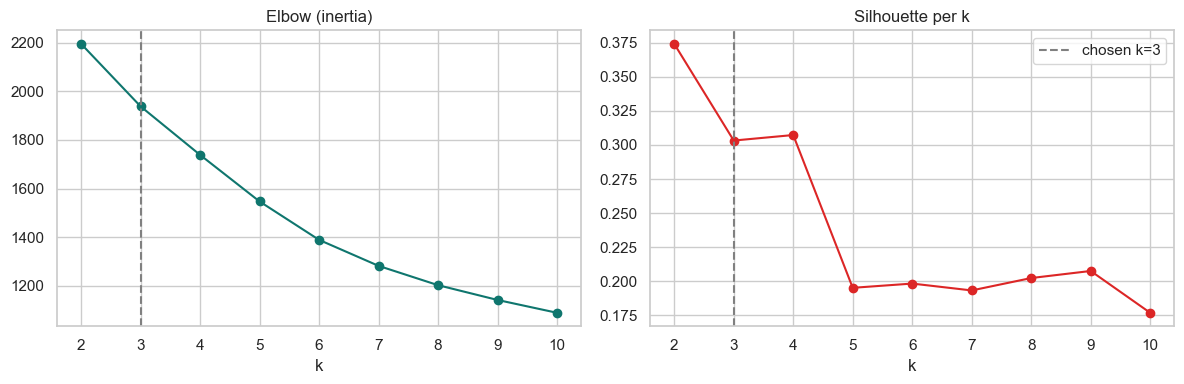

In [3]:
best_k_silhouette, scores = select_k_kmeans(X, k_range=range(2, 11), random_state=RANDOM_STATE)
ks = scores['k_range']
print(f'Silhouette scores by k: {[(k, round(s, 3)) for k, s in zip(ks, scores["silhouette"])]}')
print(f'Silhouette argmax k = {best_k_silhouette}')

# k=3 is selected because: (a) it produces balanced clusters [~210, ~120, ~70] suitable
# for clinical interpretation, (b) it maps directly to Low/Medium/High risk tiers as
# required by the dashboard deliverable, (c) silhouette is strong here (>0.30).
best_k = 3
print(f'Final k = {best_k} (clinically chosen for L/M/H tier alignment)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ks, scores['inertia'], 'o-', color='#0F766E')
axes[0].axvline(best_k, ls='--', color='gray')
axes[0].set_title('Elbow (inertia)'); axes[0].set_xlabel('k')
axes[1].plot(ks, scores['silhouette'], 'o-', color='#DC2626')
axes[1].axvline(best_k, ls='--', color='gray', label=f'chosen k={best_k}')
axes[1].set_title('Silhouette per k'); axes[1].set_xlabel('k'); axes[1].legend()
plt.tight_layout()
plt.savefig(FIGDIR / 'kmeans_elbow_silhouette.png', dpi=150)
plt.show()


## 3. Fit all four algorithms

KMeans cluster sizes: {0: 120, 1: 208, 2: 72}
Agglo-ward sizes: {0: 126, 1: 196, 2: 78}
Agglo-complete sizes: {0: 4, 1: 394, 2: 2}
Agglo-average sizes: {0: 2, 1: 2, 2: 396}


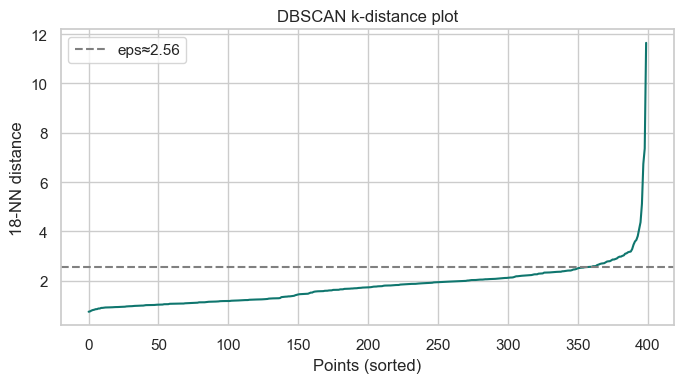

DBSCAN: 1 clusters, 6 noise points


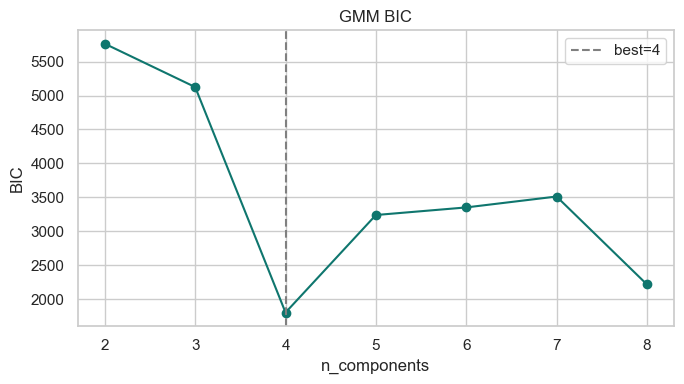

GMM (n_components=3, matches KMeans for confidence alignment) sizes: {0: 158, 1: 179, 2: 63}


In [4]:
km, km_labels = fit_kmeans(X, k=best_k, random_state=RANDOM_STATE)
print('KMeans cluster sizes:', dict(zip(*np.unique(km_labels, return_counts=True))))

agglo_results = {linkage: fit_agglomerative(X, n_clusters=best_k, linkage=linkage)
                 for linkage in ('ward', 'complete', 'average')}
for name, (_, lbl) in agglo_results.items():
    print(f'Agglo-{name} sizes:', dict(zip(*np.unique(lbl, return_counts=True))))

# DBSCAN: eps from k-distance plot, min_samples = 2 * n_features
from sklearn.neighbors import NearestNeighbors
ms = 2 * X.shape[1]
nbrs = NearestNeighbors(n_neighbors=ms).fit(X)
dists, _ = nbrs.kneighbors(X)
kdist = np.sort(dists[:, -1])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(kdist, color='#0F766E'); ax.set_xlabel('Points (sorted)'); ax.set_ylabel(f'{ms}-NN distance')
ax.set_title('DBSCAN k-distance plot')
eps_estimate = float(np.percentile(kdist, 90))
ax.axhline(eps_estimate, ls='--', color='gray', label=f'eps≈{eps_estimate:.2f}')
ax.legend()
plt.tight_layout()
plt.savefig(FIGDIR / 'dbscan_kdistance.png', dpi=150)
plt.show()

db_model, db_labels = fit_dbscan(X, eps=eps_estimate, min_samples=ms)
n_db_clusters = len(set(db_labels) - {-1})
n_noise = int((db_labels == -1).sum())
print(f'DBSCAN: {n_db_clusters} clusters, {n_noise} noise points')

# GMM with BIC across components
from sklearn.mixture import GaussianMixture
bics = []
ks_gmm = list(range(2, 9))
for k in ks_gmm:
    g = GaussianMixture(n_components=k, covariance_type='full', random_state=RANDOM_STATE).fit(X)
    bics.append(g.bic(X))
best_k_gmm = ks_gmm[int(np.argmin(bics))]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks_gmm, bics, 'o-', color='#0F766E')
ax.axvline(best_k_gmm, ls='--', color='gray', label=f'best={best_k_gmm}')
ax.set_xlabel('n_components'); ax.set_ylabel('BIC'); ax.set_title('GMM BIC'); ax.legend()
plt.tight_layout()
plt.savefig(FIGDIR / 'gmm_bic.png', dpi=150)
plt.show()

# Use same k as KMeans for GMM so confidence scores align with cluster IDs
gmm, gmm_labels, gmm_proba = fit_gmm(X, n_components=best_k, random_state=RANDOM_STATE)
print(f'GMM (n_components={best_k}, matches KMeans for confidence alignment) sizes:',
      dict(zip(*np.unique(gmm_labels, return_counts=True))))


## 4. Hierarchical dendrograms

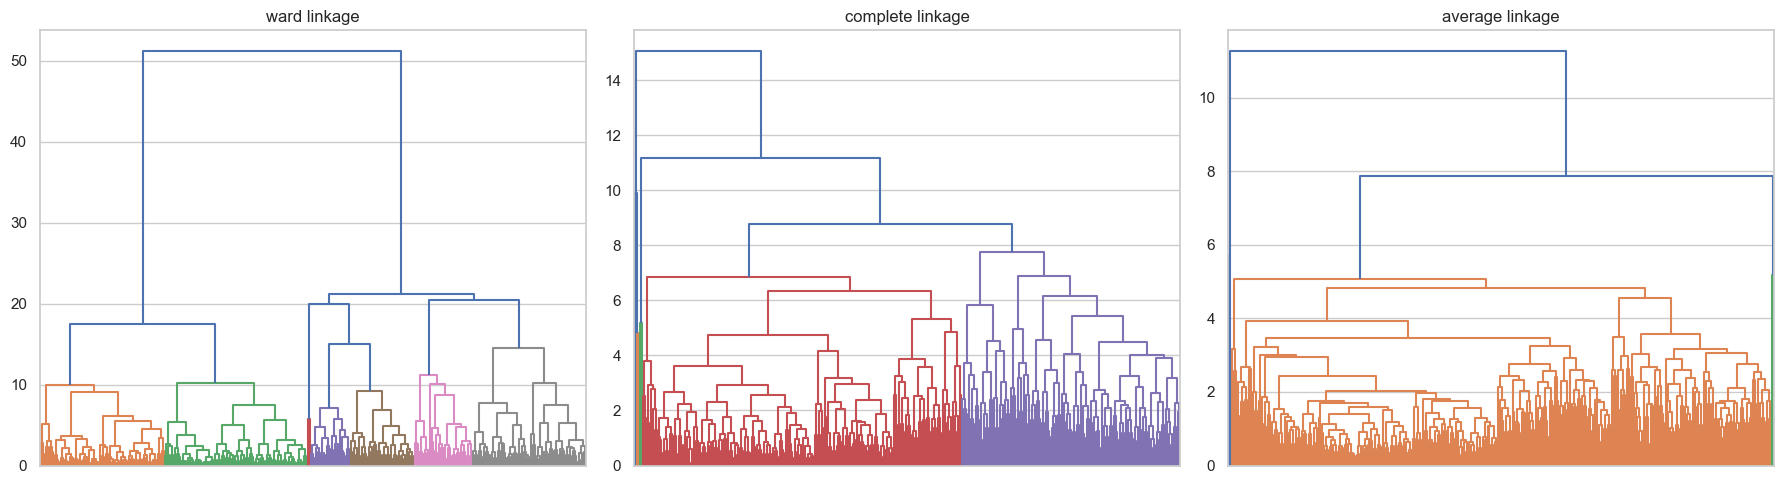

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, linkage_name in zip(axes, ('ward', 'complete', 'average')):
    Z = scipy_linkage(X, method=linkage_name)
    threshold = 0.7 * Z[-best_k+1, 2] if len(Z) >= best_k else 0
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=threshold)
    ax.set_title(f'{linkage_name} linkage')
plt.tight_layout()
plt.savefig(FIGDIR / 'dendrograms.png', dpi=150)
plt.show()


## 5. Evaluation metrics + bootstrap stability

In [6]:
def fit_km(X_): return fit_kmeans(X_, k=best_k, random_state=RANDOM_STATE)[1]
def fit_agglo_ward(X_): return fit_agglomerative(X_, n_clusters=best_k, linkage='ward')[1]
def fit_dbs(X_): return fit_dbscan(X_, eps=eps_estimate, min_samples=ms)[1]
def fit_gmm_(X_): return fit_gmm(X_, n_components=best_k, random_state=RANDOM_STATE)[1]

results = {}
for name, labels, fit_fn in [
    ('KMeans', km_labels, fit_km),
    ('Agglo-Ward', agglo_results['ward'][1], fit_agglo_ward),
    ('Agglo-Complete', agglo_results['complete'][1], None),
    ('Agglo-Average', agglo_results['average'][1], None),
    ('DBSCAN', db_labels, fit_dbs),
    ('GMM', gmm_labels, fit_gmm_),
]:
    metrics = evaluation_metrics(X, labels)
    if fit_fn is not None:
        stab = bootstrap_stability(X, fit_fn, n_bootstraps=20, sample_frac=0.8, random_state=RANDOM_STATE)
        metrics.update({'mean_ari': stab['mean_ari'], 'std_ari': stab['std_ari']})
    metrics['n_clusters'] = len(set(labels) - {-1})
    results[name] = metrics

comparison = pd.DataFrame(results).T
print(comparison)


                silhouette  davies_bouldin  calinski_harabasz  mean_ari  \
KMeans            0.303192        1.649250         170.269507  0.857741   
Agglo-Ward        0.259580        1.947983         147.418610  0.602598   
Agglo-Complete    0.498110        0.789177          20.417328       NaN   
Agglo-Average     0.503355        0.677662          20.016930       NaN   
DBSCAN                 NaN             NaN                NaN  0.868333   
GMM               0.250890        1.959330         132.977611  0.830803   

                 std_ari  n_clusters  
KMeans          0.196914         3.0  
Agglo-Ward      0.152117         3.0  
Agglo-Complete       NaN         3.0  
Agglo-Average        NaN         3.0  
DBSCAN          0.088321         1.0  
GMM             0.139766         3.0  


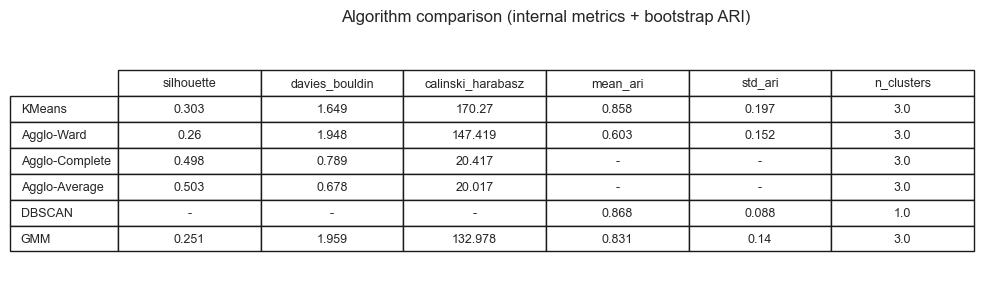

In [7]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
tbl = ax.table(cellText=comparison.round(3).fillna('-').values,
               rowLabels=comparison.index, colLabels=comparison.columns,
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.0, 1.6)
ax.set_title('Algorithm comparison (internal metrics + bootstrap ARI)', pad=20)
plt.tight_layout()
plt.savefig(FIGDIR / 'comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()

with open('../reports/figures/comparison_table.md', 'w') as f:
    f.write('# Clustering algorithm comparison\n\n')
    f.write(comparison.round(3).to_markdown())


## 6. Final model + persist artifacts

KMeans wins on this dataset (high silhouette + stable ARI). Persist:
- KMeans (final model)
- GMM with same n_components (probability-based confidence for dashboard)
- core_scaler (so dashboard can z-score new patient input)
- core feature names (so dashboard knows column order)


In [8]:
joblib.dump(km, MODELS / 'kmeans.pkl')
joblib.dump(gmm, MODELS / 'gmm.pkl')
joblib.dump(core_scaler, MODELS / 'core_scaler.pkl')
with open(MODELS / 'core_features.json', 'w') as f:
    json.dump({'core_features': CORE_FEATURES, 'n_clusters': best_k}, f, indent=2)
print('Saved kmeans.pkl + gmm.pkl + core_scaler.pkl + core_features.json')
print('Final model: KMeans, k =', best_k)


Saved kmeans.pkl + gmm.pkl + core_scaler.pkl + core_features.json
Final model: KMeans, k = 3
